# Experiment: Report 1 Training

Mục tiêu:
- Chạy line `report 1` theo pha `R1` hoặc `R2` trên `architecture_v2`.
- Giữ canonical objective/eval của `FT1/L4` để so sánh công bằng.
- Tự thích nghi giữa Colab và local CUDA; nếu là Colab thì stage dữ liệu về disk local của runtime để giảm nghẽn I/O.


In [1]:
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False

COLAB_REPO_ROOT = Path(os.environ.get("CHESS_REPO_ROOT", "/content/drive/MyDrive/chess_engine"))

if IN_COLAB:
    drive.mount("/content/drive", force_remount=False)
    if not COLAB_REPO_ROOT.exists():
        raise FileNotFoundError(
            f"Missing repo root: {COLAB_REPO_ROOT}. "
            "Set CHESS_REPO_ROOT or move the repo to this Drive path."
        )
    os.chdir(COLAB_REPO_ROOT)

print("IN_COLAB:", IN_COLAB)
print("cwd:", Path.cwd().resolve())


IN_COLAB: False
cwd: C:\Users\USER\Desktop\chess_engine\train_v4_report1


In [2]:
import importlib.util
import json
import os
import random
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "model").exists() and (candidate / "runs").exists() and (candidate / "train_v4_report1").exists():
            return candidate
    raise RuntimeError(f"Cannot find repo root from: {start}")


REPO_ROOT = find_repo_root(Path.cwd())
RUNS_ROOT = Path(os.environ.get("CHESS_RUNS_ROOT", str(REPO_ROOT / "runs")))
TRAIN_V4_DIR = REPO_ROOT / "train_v4_report1"

NVIDIA_SMI_SUMMARY = None
if shutil.which("nvidia-smi"):
    try:
        NVIDIA_SMI_SUMMARY = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
            check=True,
            capture_output=True,
            text=True,
        ).stdout.strip()
    except Exception:
        NVIDIA_SMI_SUMMARY = None

SEED = int(os.environ.get("CHESS_SEED", "123"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

torch.set_float32_matmul_precision("high")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    if NVIDIA_SMI_SUMMARY:
        raise RuntimeError(
            "CUDA is required for this notebook, but the current Python kernel does not expose CUDA. "
            f"OS-level GPU detection: {NVIDIA_SMI_SUMMARY}. Use a CUDA-enabled PyTorch kernel or Colab GPU runtime."
        )
    raise RuntimeError("CUDA is required for this notebook. Use Colab GPU or a local CUDA runtime.")

GPU_CAPABILITY = torch.cuda.get_device_capability(0)
TF32_SUPPORTED = GPU_CAPABILITY[0] >= 8
torch.backends.cuda.matmul.allow_tf32 = TF32_SUPPORTED
torch.backends.cudnn.allow_tf32 = TF32_SUPPORTED
GPU_NAME = torch.cuda.get_device_name(0)
GPU_TOTAL_MEM_GB = float(torch.cuda.get_device_properties(0).total_memory / 1024**3)

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"RUNS_ROOT = {RUNS_ROOT}")
print(f"TRAIN_V4_DIR = {TRAIN_V4_DIR}")
print(f"DEVICE = {DEVICE}")
print(f"GPU_CAPABILITY = {GPU_CAPABILITY}")
print(f"TF32_SUPPORTED = {TF32_SUPPORTED}")
print(f"GPU_NAME = {GPU_NAME}")
print(f"GPU_TOTAL_MEM_GB = {GPU_TOTAL_MEM_GB:.2f}")
print(f"NVIDIA_SMI_SUMMARY = {NVIDIA_SMI_SUMMARY}")
print(f"CPU_COUNT = {os.cpu_count()}")


REPO_ROOT = C:\Users\USER\Desktop\chess_engine
RUNS_ROOT = C:\Users\USER\Desktop\chess_engine\runs
TRAIN_V4_DIR = C:\Users\USER\Desktop\chess_engine\train_v4_report1
DEVICE = cuda
GPU_CAPABILITY = (8, 6)
TF32_SUPPORTED = True
GPU_NAME = NVIDIA GeForce RTX 2050
GPU_TOTAL_MEM_GB = 4.00
NVIDIA_SMI_SUMMARY = NVIDIA GeForce RTX 2050, 4096 MiB, 566.07
CPU_COUNT = 12


In [3]:
def env_bool(name: str, default: bool) -> bool:
    raw = os.environ.get(name, "").strip().lower()
    if not raw:
        return bool(default)
    return raw in {"1", "true", "yes", "y"}


DATA_ROOT_OVERRIDE = os.environ.get("CHESS_DATA_ROOT", "").strip()
DATA_ROOT = Path(DATA_ROOT_OVERRIDE) if DATA_ROOT_OVERRIDE else (REPO_ROOT / "data" / "process")
STAGE_DATA_LOCAL = IN_COLAB and env_bool("CHESS_STAGE_DATA_LOCAL", True)
FORCE_RESTAGE = env_bool("CHESS_FORCE_RESTAGE", False)
LOCAL_DATA_ROOT = Path(os.environ.get("CHESS_LOCAL_DATA_ROOT", "/content/chess_engine_data/process"))

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Missing data root: {DATA_ROOT}. "
        "Set CHESS_DATA_ROOT or place the shards under REPO_ROOT/data/process."
    )

DATA_ROOT_ACTIVE = DATA_ROOT
if STAGE_DATA_LOCAL:
    if FORCE_RESTAGE and LOCAL_DATA_ROOT.exists():
        shutil.rmtree(LOCAL_DATA_ROOT)
    local_ready = all((LOCAL_DATA_ROOT / split).exists() for split in ("train", "val", "test"))
    if not local_ready:
        LOCAL_DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
        src = str(DATA_ROOT).rstrip("/\\") + "/"
        dst = str(LOCAL_DATA_ROOT).rstrip("/\\") + "/"
        if shutil.which("rsync"):
            print(f"Staging dataset to local runtime disk via rsync: {DATA_ROOT} -> {LOCAL_DATA_ROOT}")
            subprocess.run(["rsync", "-a", "--delete", src, dst], check=True)
        else:
            print(f"Staging dataset to local runtime disk via shutil: {DATA_ROOT} -> {LOCAL_DATA_ROOT}")
            shutil.copytree(DATA_ROOT, LOCAL_DATA_ROOT, dirs_exist_ok=True)
    DATA_ROOT_ACTIVE = LOCAL_DATA_ROOT


def _sorted_npy_files(split_dir: Path, pattern: str):
    return sorted(split_dir.glob(pattern), key=lambda p: p.name)


def scan_split(split: str):
    split_dir = DATA_ROOT_ACTIVE / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split dir: {split_dir}")
    x_files = _sorted_npy_files(split_dir, "X_*.npy")
    y_files = _sorted_npy_files(split_dir, "y_*.npy")
    if len(x_files) == 0 or len(y_files) == 0:
        raise FileNotFoundError(f"No shards found in {split_dir}. Expect X_*.npy and y_*.npy")
    if len(x_files) != len(y_files):
        raise ValueError(f"Shard count mismatch in {split}: X={len(x_files)} vs y={len(y_files)}")

    shard_sizes = []
    for xf, yf in zip(x_files, y_files):
        X = np.load(xf, mmap_mode="r")
        y = np.load(yf, mmap_mode="r")
        if X.ndim != 4 or X.shape[1:] != (18, 8, 8):
            raise ValueError(f"Bad X shape at {xf.name}: {X.shape} (expect (N,18,8,8))")
        if y.ndim != 1:
            raise ValueError(f"Bad y shape at {yf.name}: {y.shape} (expect (N,))")
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"N mismatch at {xf.name} vs {yf.name}: {X.shape[0]} vs {y.shape[0]}")
        shard_sizes.append(int(X.shape[0]))

    return {
        "split": split,
        "num_shards": len(x_files),
        "num_samples": int(sum(shard_sizes)),
        "first_shard": x_files[0].name,
        "last_shard": x_files[-1].name,
        "min_shard_size": int(min(shard_sizes)),
        "max_shard_size": int(max(shard_sizes)),
    }


split_rows = [scan_split(split) for split in ("train", "val", "test")]
print(f"DATA_ROOT = {DATA_ROOT}")
print(f"DATA_ROOT_ACTIVE = {DATA_ROOT_ACTIVE}")
print(f"STAGE_DATA_LOCAL = {STAGE_DATA_LOCAL}")
display(pd.DataFrame(split_rows))


DATA_ROOT = C:\Users\USER\Desktop\chess_engine\data\process
DATA_ROOT_ACTIVE = C:\Users\USER\Desktop\chess_engine\data\process
STAGE_DATA_LOCAL = False


,split,num_shards,num_samples,first_shard,last_shard,min_shard_size,max_shard_size
0,train,80,4000000,X_00000.npy,X_00079.npy,50000,50000
1,val,10,500000,X_00000.npy,X_00009.npy,50000,50000
2,test,10,500000,X_00000.npy,X_00009.npy,50000,50000


In [4]:
def resolve_train_v4_helper_path(repo_root: Path) -> Path:
    candidates = []
    env_dir = os.environ.get("CHESS_TRAIN_V4_DIR", "").strip()
    if env_dir:
        candidates.append(repo_root / env_dir / "report1_train_helpers.py")
    candidates.append(repo_root / "train_v4_report1" / "report1_train_helpers.py")
    seen = set()
    for path in candidates:
        key = str(path)
        if key in seen:
            continue
        seen.add(key)
        if path.exists():
            return path
    raise FileNotFoundError(f"Cannot find report1_train_helpers.py under {repo_root}. Tried: {candidates}")


def load_report1_helper(repo_root: Path):
    helper_name = "report1_train_helpers"
    helper_path = resolve_train_v4_helper_path(repo_root)
    if helper_name in sys.modules:
        del sys.modules[helper_name]
    spec = importlib.util.spec_from_file_location(helper_name, helper_path)
    lab = importlib.util.module_from_spec(spec)
    sys.modules[helper_name] = lab
    assert spec.loader is not None
    spec.loader.exec_module(lab)
    return lab, helper_path


def env_int(name: str, default: int) -> int:
    raw = os.environ.get(name, "").strip()
    return int(raw) if raw else int(default)


def env_optional_int(name: str, default):
    raw = os.environ.get(name, "").strip()
    return int(raw) if raw else default


def env_float(name: str, default: float) -> float:
    raw = os.environ.get(name, "").strip()
    return float(raw) if raw else float(default)


lab, HELPER_PATH = load_report1_helper(REPO_ROOT)

PHASE = os.environ.get("CHESS_REPORT1_PHASE", "R2").strip().upper()
PHASE_PRESETS = {
    "R1": {
        "run_name": "dgrn_5m_report1_r1_shrink_run1",
        "epochs": 15,
        "sampling_mode": "band_balanced",
    },
    "R2": {
        "run_name": "dgrn_5m_report1_r2_sign_run1",
        "epochs": 12,
        "sampling_mode": "sign_stratified",
    },
}
if PHASE not in PHASE_PRESETS:
    raise ValueError(f"Unsupported CHESS_REPORT1_PHASE={PHASE}. Use one of: {sorted(PHASE_PRESETS)}")
preset = PHASE_PRESETS[PHASE]

RUN_NAME = os.environ.get("CHESS_RUN_NAME", f"{preset['run_name']}_local_opt")
RUN_DIR = RUNS_ROOT / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
LATEST_CKPT = RUN_DIR / "checkpoints" / "ckpt_latest.pt"
RUN_CONFIG_PATH = RUN_DIR / "reports" / "run_config.json"
RESUME_IF_EXISTS = env_bool("CHESS_RESUME_IF_EXISTS", False)

saved_train_cfg = {}
saved_runtime_cfg = {}
RESUME_PROFILE_LOADED = False
if RESUME_IF_EXISTS and LATEST_CKPT.exists() and RUN_CONFIG_PATH.exists():
    saved_run_config = json.loads(RUN_CONFIG_PATH.read_text(encoding="utf-8"))
    saved_train_cfg = dict(saved_run_config.get("train_cfg", {}))
    saved_runtime_cfg = dict(saved_run_config.get("runtime", {}))
    RESUME_PROFILE_LOADED = True
    print("[resume-config] Reusing saved report1 train profile from run_config.json")
    saved_gpu_name = str(saved_runtime_cfg.get("gpu_name", ""))
    saved_mem_gb = float(saved_runtime_cfg.get("total_mem_gb", GPU_TOTAL_MEM_GB)) if saved_runtime_cfg else GPU_TOTAL_MEM_GB
    if saved_gpu_name and (saved_gpu_name != GPU_NAME or abs(saved_mem_gb - GPU_TOTAL_MEM_GB) > 0.5):
        print(
            "[resume-config][warning] Existing run profile was tuned on different hardware. "
            f"saved=({saved_gpu_name}, {saved_mem_gb:.2f} GB) current=({GPU_NAME}, {GPU_TOTAL_MEM_GB:.2f} GB). "
            "For maximal throughput on this runtime, start a new run_name instead of resuming the old profile."
        )


def saved_or_default(name: str, fallback):
    return saved_train_cfg.get(name, fallback)


BASE_TRAIN_CFG = lab.Report1TrainConfig(
    run_name=RUN_NAME,
    phase_name=PHASE,
    epochs=int(preset["epochs"]),
    sampling_mode=str(preset["sampling_mode"]),
)

MODEL_CFG = {
    "num_blocks": 8,
    "hidden_dim": 128,
    "input_channels": 18,
    "drop_path_rate": 0.05,
    "output_mode": "tanh",
}

AUTOTUNE_PROFILE = (
    DEVICE.type == "cuda"
    and (not env_bool("CHESS_DISABLE_PROFILE_AUTOTUNE", False))
    and (not RESUME_PROFILE_LOADED)
)

TRAIN_CFG = lab.Report1TrainConfig(
    run_name=RUN_NAME,
    phase_name=PHASE,
    epochs=env_int("CHESS_EPOCHS", int(saved_or_default("epochs", BASE_TRAIN_CFG.epochs))),
    sampling_mode=os.environ.get("CHESS_SAMPLING_MODE", str(saved_or_default("sampling_mode", BASE_TRAIN_CFG.sampling_mode))),
    main_batch_size=env_int("CHESS_MAIN_BATCH_SIZE", int(saved_or_default("main_batch_size", BASE_TRAIN_CFG.main_batch_size))),
    clean_center_batch_size=env_int("CHESS_CLEAN_CENTER_BATCH_SIZE", int(saved_or_default("clean_center_batch_size", BASE_TRAIN_CFG.clean_center_batch_size))),
    ambiguous_center_batch_size=env_int("CHESS_AMBIGUOUS_CENTER_BATCH_SIZE", int(saved_or_default("ambiguous_center_batch_size", BASE_TRAIN_CFG.ambiguous_center_batch_size))),
    grad_accum_steps=env_int("CHESS_GRAD_ACCUM_STEPS", int(saved_or_default("grad_accum_steps", BASE_TRAIN_CFG.grad_accum_steps))),
    eval_batch_size=env_int("CHESS_EVAL_BATCH_SIZE", int(saved_or_default("eval_batch_size", BASE_TRAIN_CFG.eval_batch_size))),
    learning_rate=env_float("CHESS_LR", float(saved_or_default("learning_rate", BASE_TRAIN_CFG.learning_rate))),
    min_lr=env_float("CHESS_MIN_LR", float(saved_or_default("min_lr", BASE_TRAIN_CFG.min_lr))),
    weight_decay=env_float("CHESS_WEIGHT_DECAY", float(saved_or_default("weight_decay", BASE_TRAIN_CFG.weight_decay))),
    grad_clip_norm=env_float("CHESS_GRAD_CLIP_NORM", float(saved_or_default("grad_clip_norm", BASE_TRAIN_CFG.grad_clip_norm))),
    seed=env_int("CHESS_SEED", int(saved_or_default("seed", SEED))),
    train_num_shards=env_optional_int("CHESS_TRAIN_NUM_SHARDS", saved_or_default("train_num_shards", BASE_TRAIN_CFG.train_num_shards)),
    val_num_shards=env_int("CHESS_VAL_NUM_SHARDS", int(saved_or_default("val_num_shards", BASE_TRAIN_CFG.val_num_shards))),
    test_num_shards=env_int("CHESS_TEST_NUM_SHARDS", int(saved_or_default("test_num_shards", BASE_TRAIN_CFG.test_num_shards))),
    val_max_samples=env_int("CHESS_VAL_MAX_SAMPLES", int(saved_or_default("val_max_samples", BASE_TRAIN_CFG.val_max_samples))),
    test_max_samples=env_int("CHESS_TEST_MAX_SAMPLES", int(saved_or_default("test_max_samples", BASE_TRAIN_CFG.test_max_samples))),
    log_every_steps=env_int("CHESS_LOG_EVERY_STEPS", int(saved_or_default("log_every_steps", BASE_TRAIN_CFG.log_every_steps))),
    grad_monitor_every_steps=env_int("CHESS_GRAD_MONITOR_EVERY_STEPS", int(saved_or_default("grad_monitor_every_steps", BASE_TRAIN_CFG.grad_monitor_every_steps))),
    use_amp=env_bool("CHESS_USE_AMP", bool(saved_or_default("use_amp", BASE_TRAIN_CFG.use_amp))),
    amp_dtype=os.environ.get("CHESS_AMP_DTYPE", str(saved_or_default("amp_dtype", BASE_TRAIN_CFG.amp_dtype))),
    amp_loss_scale=env_float("CHESS_AMP_LOSS_SCALE", float(saved_or_default("amp_loss_scale", BASE_TRAIN_CFG.amp_loss_scale))),
    preload_shard_dtype=os.environ.get("CHESS_PRELOAD_SHARD_DTYPE", str(saved_or_default("preload_shard_dtype", BASE_TRAIN_CFG.preload_shard_dtype))),
    channels_last=env_bool("CHESS_CHANNELS_LAST", bool(saved_or_default("channels_last", BASE_TRAIN_CFG.channels_last))),
    cudnn_benchmark=env_bool("CHESS_CUDNN_BENCHMARK", bool(saved_or_default("cudnn_benchmark", BASE_TRAIN_CFG.cudnn_benchmark))),
    pin_memory_batches=env_bool("CHESS_PIN_MEMORY_BATCHES", bool(saved_or_default("pin_memory_batches", BASE_TRAIN_CFG.pin_memory_batches))),
    prefetch_shards=env_bool("CHESS_PREFETCH_SHARDS", bool(saved_or_default("prefetch_shards", BASE_TRAIN_CFG.prefetch_shards))),
    prefetch_workers=env_int("CHESS_PREFETCH_WORKERS", int(saved_or_default("prefetch_workers", BASE_TRAIN_CFG.prefetch_workers))),
    benchmark_steps=env_int("CHESS_BENCHMARK_STEPS", int(saved_or_default("benchmark_steps", BASE_TRAIN_CFG.benchmark_steps))),
    benchmark_warmup_steps=env_int("CHESS_BENCHMARK_WARMUP_STEPS", int(saved_or_default("benchmark_warmup_steps", BASE_TRAIN_CFG.benchmark_warmup_steps))),
    benchmark_num_shards=env_int("CHESS_BENCHMARK_NUM_SHARDS", int(saved_or_default("benchmark_num_shards", BASE_TRAIN_CFG.benchmark_num_shards))),
    max_profile_mem_ratio=env_float("CHESS_MAX_PROFILE_MEM_RATIO", float(saved_or_default("max_profile_mem_ratio", BASE_TRAIN_CFG.max_profile_mem_ratio))),
    periodic_save_minutes=env_int("CHESS_PERIODIC_SAVE_MINUTES", int(saved_or_default("periodic_save_minutes", 30))),
    save_epoch_checkpoints=env_bool("CHESS_SAVE_EPOCH_CHECKPOINTS", bool(saved_or_default("save_epoch_checkpoints", False))),
    resume_if_exists=RESUME_IF_EXISTS,
    main_center_tau_y600=env_float("CHESS_MAIN_CENTER_TAU_Y600", float(saved_or_default("main_center_tau_y600", BASE_TRAIN_CFG.main_center_tau_y600))),
    main_center_min_weight=env_float("CHESS_MAIN_CENTER_MIN_WEIGHT", float(saved_or_default("main_center_min_weight", BASE_TRAIN_CFG.main_center_min_weight))),
    main_center_weight_power=env_float("CHESS_MAIN_CENTER_WEIGHT_POWER", float(saved_or_default("main_center_weight_power", BASE_TRAIN_CFG.main_center_weight_power))),
    lambda_clean_center=env_float("CHESS_LAMBDA_CLEAN_CENTER", float(saved_or_default("lambda_clean_center", BASE_TRAIN_CFG.lambda_clean_center))),
    lambda_ambiguous_center=env_float("CHESS_LAMBDA_AMBIGUOUS_CENTER", float(saved_or_default("lambda_ambiguous_center", BASE_TRAIN_CFG.lambda_ambiguous_center))),
    aux_margin_y600=env_float("CHESS_AUX_MARGIN_Y600", float(saved_or_default("aux_margin_y600", BASE_TRAIN_CFG.aux_margin_y600))),
    aux_margin_weight=env_float("CHESS_AUX_MARGIN_WEIGHT", float(saved_or_default("aux_margin_weight", BASE_TRAIN_CFG.aux_margin_weight))),
    aux_huber_delta=env_float("CHESS_AUX_HUBER_DELTA", float(saved_or_default("aux_huber_delta", BASE_TRAIN_CFG.aux_huber_delta))),
    aux_ramp_epochs=env_int("CHESS_AUX_RAMP_EPOCHS", int(saved_or_default("aux_ramp_epochs", BASE_TRAIN_CFG.aux_ramp_epochs))),
    use_backbone_pcgrad=env_bool("CHESS_USE_BACKBONE_PCGRAD", bool(saved_or_default("use_backbone_pcgrad", BASE_TRAIN_CFG.use_backbone_pcgrad))),
    pcgrad_eps=env_float("CHESS_PCGRAD_EPS", float(saved_or_default("pcgrad_eps", BASE_TRAIN_CFG.pcgrad_eps))),
)
GATE_CFG = lab.Report1GateConfig(
    midband_mae_rel_tol=env_float("CHESS_GATE_MIDBAND_REL_TOL", 0.05),
    stable_slope_abs_tol=env_float("CHESS_GATE_STABLE_SLOPE_ABS_TOL", 0.02),
)
lab.validate_report1_train_config(TRAIN_CFG)

config_rows = [
    {"section": "runtime", "key": "phase", "value": PHASE},
    {"section": "runtime", "key": "run_name", "value": RUN_NAME},
    {"section": "runtime", "key": "resume_if_exists", "value": TRAIN_CFG.resume_if_exists},
    {"section": "runtime", "key": "autotune_profile", "value": AUTOTUNE_PROFILE},
    {"section": "runtime", "key": "data_root_active", "value": str(DATA_ROOT_ACTIVE)},
    {"section": "model", "key": "num_blocks", "value": MODEL_CFG["num_blocks"]},
    {"section": "model", "key": "hidden_dim", "value": MODEL_CFG["hidden_dim"]},
    {"section": "train", "key": "sampling_mode", "value": TRAIN_CFG.sampling_mode},
    {"section": "train", "key": "epochs", "value": TRAIN_CFG.epochs},
    {"section": "train", "key": "main_batch_size", "value": TRAIN_CFG.main_batch_size},
    {"section": "train", "key": "clean_center_batch_size", "value": TRAIN_CFG.clean_center_batch_size},
    {"section": "train", "key": "ambiguous_center_batch_size", "value": TRAIN_CFG.ambiguous_center_batch_size},
    {"section": "train", "key": "grad_accum_steps", "value": TRAIN_CFG.grad_accum_steps},
    {"section": "train", "key": "eval_batch_size", "value": TRAIN_CFG.eval_batch_size},
    {"section": "train", "key": "preload_shard_dtype", "value": TRAIN_CFG.preload_shard_dtype},
    {"section": "train", "key": "pin_memory_batches", "value": TRAIN_CFG.pin_memory_batches},
    {"section": "train", "key": "prefetch_workers", "value": TRAIN_CFG.prefetch_workers},
    {"section": "train", "key": "benchmark_steps", "value": TRAIN_CFG.benchmark_steps},
    {"section": "train", "key": "benchmark_warmup_steps", "value": TRAIN_CFG.benchmark_warmup_steps},
    {"section": "train", "key": "benchmark_num_shards", "value": TRAIN_CFG.benchmark_num_shards},
    {"section": "train", "key": "max_profile_mem_ratio", "value": TRAIN_CFG.max_profile_mem_ratio},
    {"section": "train", "key": "periodic_save_minutes", "value": TRAIN_CFG.periodic_save_minutes},
]
print(f"HELPER_PATH = {HELPER_PATH}")
display(pd.DataFrame(config_rows))


HELPER_PATH = C:\Users\USER\Desktop\chess_engine\train_v4_report1\report1_train_helpers.py


,section,key,value
0,runtime,phase,R2
1,runtime,run_name,dgrn_5m_report1_r2_sign_run1_local_opt
2,runtime,resume_if_exists,False
3,runtime,autotune_profile,True
4,runtime,data_root_active,C:\Users\USER\Desktop\chess_engine\data\process
5,model,num_blocks,8
6,model,hidden_dim,128
7,train,sampling_mode,sign_stratified
8,train,epochs,12
9,train,main_batch_size,768


In [5]:
run_artifacts = lab.run_report1_training(
    repo_root=REPO_ROOT,
    runs_root=RUNS_ROOT,
    data_root=DATA_ROOT_ACTIVE,
    model_cfg=MODEL_CFG,
    train_cfg=TRAIN_CFG,
    gate_cfg=GATE_CFG,
    autotune_profile=AUTOTUNE_PROFILE,
)

RUN_DIR = Path(run_artifacts["paths"]["run_dir"])
SELECTED_CHECKPOINT = Path(run_artifacts["selected_checkpoint"])
print("Run finished.")
print("Run dir:", RUN_DIR)
print("Selected checkpoint:", SELECTED_CHECKPOINT)
print("Final center_score:", run_artifacts["final_eval"].get("center_score"))
print("Final oracle_midband_mae_sum_stable:", run_artifacts["final_eval"].get("oracle_midband_mae_sum_stable"))
print("Final oracle_stable_0.7_slope:", run_artifacts["final_eval"].get("oracle_stable_0.7_slope"))


[val_600] offset=0 / 100000 elapsed=1.2s
[val_600] offset=32000 / 100000 elapsed=17.6s
[val_600] offset=64000 / 100000 elapsed=34.1s
[val_600] offset=96000 / 100000 elapsed=50.6s
[oracle_subset_600] offset=0 / 240 elapsed=0.3s
[report1][epoch=0] step=200 main_obj=0.255113 aux_obj=0.000763
[report1][epoch=0] step=400 main_obj=0.222862 aux_obj=0.000981
[report1][epoch=0] step=600 main_obj=0.218782 aux_obj=0.001007
[report1][epoch=0] step=800 main_obj=0.206512 aux_obj=0.000986
[report1][epoch=0] step=1000 main_obj=0.201995 aux_obj=0.000979
[report1][epoch=0] step=1200 main_obj=0.196216 aux_obj=0.000961
[report1][epoch=0] step=1400 main_obj=0.191681 aux_obj=0.000951
[report1][epoch=0] step=1600 main_obj=0.188181 aux_obj=0.000943
[report1][epoch=0] step=1800 main_obj=0.183866 aux_obj=0.000935
[report1][epoch=0] step=2000 main_obj=0.181830 aux_obj=0.000917
[report1][epoch=0] step=2200 main_obj=0.178272 aux_obj=0.000909
[report1][epoch=0] step=2400 main_obj=0.177079 aux_obj=0.000895
[report1]

Decision summary:
{
  "best_any_center_score": 0.19007289281666656,
  "best_gate_center_score": null,
  "best_pareto_A_midband": 0.635966096003993,
  "best_pareto_A_slope": 0.5463286093609894,
  "best_pareto_B_center_score": 0.19007289281666656,
  "has_best_gate": false,
  "latest_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\runs\\dgrn_5m_report1_r2_sign_run1_local_opt\\checkpoints\\ckpt_latest.pt",
  "best_any_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\runs\\dgrn_5m_report1_r2_sign_run1_local_opt\\checkpoints\\ckpt_best_any.pt",
  "best_gate_checkpoint": null,
  "best_pareto_A_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\runs\\dgrn_5m_report1_r2_sign_run1_local_opt\\checkpoints\\ckpt_best_pareto_A.pt",
  "best_pareto_B_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\runs\\dgrn_5m_report1_r2_sign_run1_local_opt\\checkpoints\\ckpt_best_pareto_B.pt",
  "last_epoch": 11,
  "last_center_score": 0.19007289281666656,
  "last_gate_pass": false,
  "selected_c

,epoch,global_step,lr,epoch_time_sec,optimizer_steps_per_sec,main_samples_per_sec,train_total_objective,train_main_objective,train_aux_objective,train_clean_loss,...,clean_center_false_0.1eq,clean_center_false_0.2eq,ambiguous_center_mae,ambiguous_center_amp_ratio,ambiguous_center_false_0.1eq,ambiguous_center_false_0.2eq,grad_conflict_backbone,grad_cosine_backbone,grad_cosine_backbone_post,grad_cosine_all
7,7,50240,0.000033,10553.006149,0.595091,379.038915,0.099516,0.099193,0.000323,0.000847,...,0.025641,0.0,0.033368,0.871713,0.512821,0.051282,0.142857,0.528528,0.603061,0.434609
8,8,56520,0.000023,10507.132437,0.597689,380.693783,0.096538,0.096267,0.000270,0.000725,...,0.102564,0.0,0.034537,1.004326,0.538462,0.128205,0.333333,0.239675,0.381644,0.305333
9,9,62800,0.000016,10500.244916,0.598081,380.943495,0.094133,0.093895,0.000238,0.000638,...,0.102564,0.0,0.036034,1.018800,0.564103,0.076923,0.500000,-0.012938,0.242895,0.082542
10,10,69080,0.000012,10478.642902,0.599314,381.728821,0.092148,0.091942,0.000207,0.000543,...,0.076923,0.0,0.042155,1.037075,0.564103,0.102564,0.285714,0.334833,0.467493,0.452690
11,11,75360,0.000010,10365.927990,0.605831,385.879586,0.090771,0.090583,0.000188,0.000486,...,0.025641,0.0,0.041482,1.047891,0.564103,0.076923,0.500000,0.006030,0.349556,0.117136


,label,oracle_midband_mae_sum_stable,oracle_stable_0.7_slope,oracle_center_amp_ratio,oracle_center_false_0.1eq,oracle_center_false_0.2eq,pooled_center_mae,pooled_center_amp_ratio,pooled_center_false_0.1eq,pooled_center_false_0.2eq,center_score,clean_center_mae,clean_center_amp_ratio,clean_center_false_0.1eq,ambiguous_center_mae,ambiguous_center_amp_ratio,ambiguous_center_false_0.1eq
0,L4_reference,0.571198,0.617710,6.376511,0.588235,0.235294,0.108940,4.798148,0.500000,0.227273,0.534209,0.351239,13.802596,0.769231,0.232995,2.559872,0.743590
1,R2_selected,0.640695,0.480992,6.911872,0.617647,0.235294,0.128615,5.835119,0.590909,0.272727,0.693945,0.036783,1.676698,0.025641,0.041479,1.047867,0.564103


,main_batch_size,clean_center_batch_size,ambiguous_center_batch_size,grad_accum_steps,eval_batch_size,main_positions_per_sec,peak_mem_gb,peak_mem_ratio,epoch_hours_estimate,ok
0,320,40,80,2,1280,392.638105,1.050695,0.262706,2.829861,True
1,288,36,72,2,1280,391.945168,0.952262,0.238095,2.834864,True
4,192,24,48,2,1024,390.655931,0.658185,0.164566,2.844219,True
3,224,28,56,2,1024,390.275689,0.776209,0.194076,2.846990,True
5,160,20,40,2,768,386.891932,0.548300,0.137092,2.871890,True
2,256,32,64,2,1280,382.404332,0.880013,0.220030,2.905592,True
6,128,16,32,2,768,369.763362,0.463701,0.115939,3.004925,True


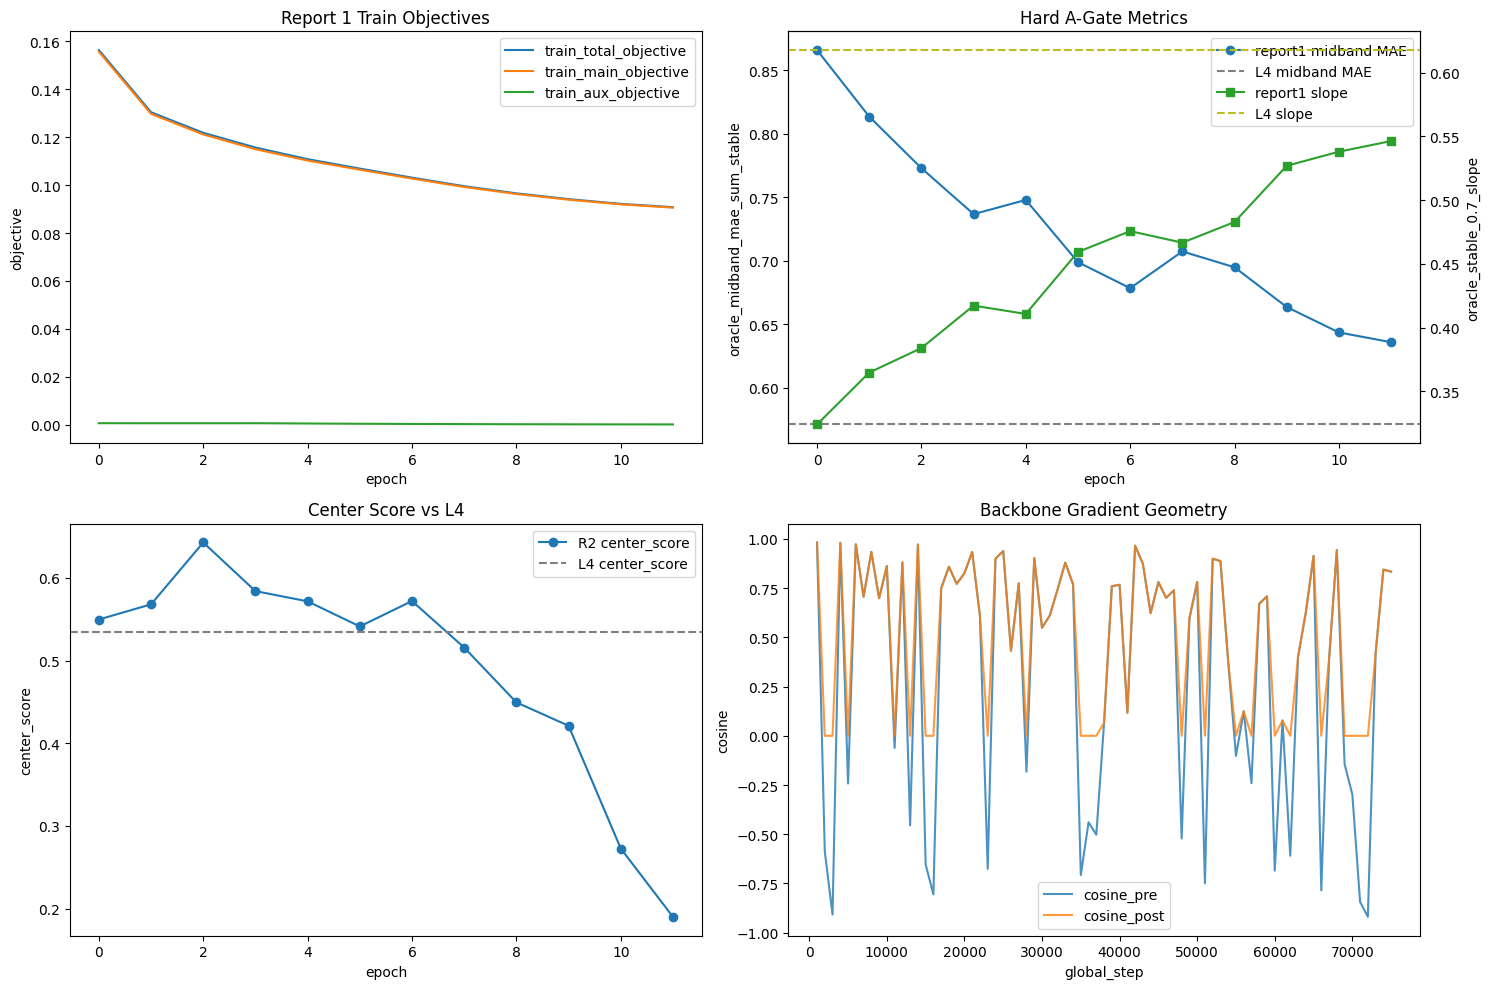

In [6]:
reports_dir = RUN_DIR / "reports"
history_df = pd.read_csv(reports_dir / "history.csv")
step_history_path = reports_dir / "step_history.csv"
step_hist = pd.read_csv(step_history_path) if step_history_path.exists() else pd.DataFrame()
decision = json.loads((reports_dir / "decision_summary.json").read_text(encoding="utf-8"))
l4_ref = json.loads((reports_dir / "l4_reference.json").read_text(encoding="utf-8"))
selected_eval = json.loads((reports_dir / "selected_checkpoint_eval.json").read_text(encoding="utf-8"))
autotune_path = reports_dir / "train_batch_autotune.json"
autotune = json.loads(autotune_path.read_text(encoding="utf-8")) if autotune_path.exists() else None

print("Decision summary:")
print(json.dumps(decision, indent=2, ensure_ascii=False))
display(history_df.tail(5))

compare_keys = [
    "oracle_midband_mae_sum_stable",
    "oracle_stable_0.7_slope",
    "oracle_center_amp_ratio",
    "oracle_center_false_0.1eq",
    "oracle_center_false_0.2eq",
    "pooled_center_mae",
    "pooled_center_amp_ratio",
    "pooled_center_false_0.1eq",
    "pooled_center_false_0.2eq",
    "center_score",
    "clean_center_mae",
    "clean_center_amp_ratio",
    "clean_center_false_0.1eq",
    "ambiguous_center_mae",
    "ambiguous_center_amp_ratio",
    "ambiguous_center_false_0.1eq",
]
compare = pd.DataFrame([
    {"label": "L4_reference", **{k: l4_ref.get(k, l4_ref.get("primary", {}).get(k)) for k in compare_keys}},
    {"label": f"{PHASE}_selected", **{k: selected_eval.get(k) for k in compare_keys}},
])
display(compare.round(6))

if autotune is not None and autotune.get("candidates"):
    autotune_df = pd.DataFrame(autotune["candidates"])
    display(autotune_df[[c for c in [
        "main_batch_size",
        "clean_center_batch_size",
        "ambiguous_center_batch_size",
        "grad_accum_steps",
        "eval_batch_size",
        "main_positions_per_sec",
        "peak_mem_gb",
        "peak_mem_ratio",
        "epoch_hours_estimate",
        "ok",
        "oom",
    ] if c in autotune_df.columns]].sort_values("main_positions_per_sec", ascending=False, na_position="last"))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history_df["epoch"], history_df["train_total_objective"], label="train_total_objective")
axes[0, 0].plot(history_df["epoch"], history_df["train_main_objective"], label="train_main_objective")
axes[0, 0].plot(history_df["epoch"], history_df["train_aux_objective"], label="train_aux_objective")
axes[0, 0].set_title("Report 1 Train Objectives")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("objective")
axes[0, 0].legend()

axes[0, 1].plot(history_df["epoch"], history_df["oracle_midband_mae_sum_stable"], marker="o", label="report1 midband MAE")
axes[0, 1].axhline(float(l4_ref["primary"]["oracle_midband_mae_sum_stable"]), color="tab:gray", linestyle="--", label="L4 midband MAE")
ax2 = axes[0, 1].twinx()
ax2.plot(history_df["epoch"], history_df["oracle_stable_0.7_slope"], marker="s", color="tab:green", label="report1 slope")
ax2.axhline(float(l4_ref["primary"]["oracle_stable_0.7_slope"]), color="tab:olive", linestyle="--", label="L4 slope")
axes[0, 1].set_title("Hard A-Gate Metrics")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("oracle_midband_mae_sum_stable")
ax2.set_ylabel("oracle_stable_0.7_slope")
lines1, labels1 = axes[0, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0, 1].legend(lines1 + lines2, labels1 + labels2, loc="best")

axes[1, 0].plot(history_df["epoch"], history_df["center_score"], marker="o", label=f"{PHASE} center_score")
axes[1, 0].axhline(float(l4_ref["primary"]["center_score"]), color="tab:gray", linestyle="--", label="L4 center_score")
axes[1, 0].set_title("Center Score vs L4")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("center_score")
axes[1, 0].legend()

if len(step_hist) > 0:
    axes[1, 1].plot(step_hist["global_step"], step_hist["grad_cosine_backbone_pre"], alpha=0.8, label="cosine_pre")
    axes[1, 1].plot(step_hist["global_step"], step_hist["grad_cosine_backbone_post"], alpha=0.8, label="cosine_post")
    axes[1, 1].set_title("Backbone Gradient Geometry")
    axes[1, 1].set_xlabel("global_step")
    axes[1, 1].set_ylabel("cosine")
    axes[1, 1].legend(loc="best")
else:
    axes[1, 1].text(0.5, 0.5, "No step_history rows yet", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()
